# Wingspan Bird Card Power Value Regression

**Goal:** Estimate the implicit value of bird powers (in victory points) by modeling the
relationship between a bird's victory points and its measurable attributes.

**Approach — Three-stage linear regression:**

1. **Stage 1 (Baseline):** Regress VP on non-power attributes (food cost, nest, wingspan,
   egg capacity, bonus eligibility). This establishes the VP-cost tradeoff for all birds.
2. **Stage 2 (Power Color):** Add power color dummies (brown, white, teal, pink, yellow)
   with powerless birds as the reference group. Coefficients estimate the average VP
   adjustment for each power color.
3. **Stage 3 (Power Text — future):** Parse power text to extract specific mechanics and
   estimate per-mechanic value.

**Key assumptions:**
- Playing with Oceania/Asia expansions (affects dice/food rarity)
- Food costs weighted by dice availability (rarer foods cost more)
- Game designers used roughly linear tradeoffs in card balancing
- Nectar has special properties (wild input, habitat majority scoring, expiration risk)

In [30]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from src.load_data import load_bird_data
from src.features import build_feature_matrix, get_food_rarity_summary, FOOD_RARITY_WEIGHT

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Data Loading & Feature Engineering

In [31]:
raw = load_bird_data()
feat = build_feature_matrix(raw)
print(f"Dataset: {len(feat)} birds, {len(feat.columns)} features")
feat.head()

Dataset: 596 birds, 25 features


,common_name,victory_points,color,power_text,weighted_food_cost,total_food_cost,has_or_cost,has_predator_cost,nectar_required,egg_limit,star_nest,nest_none,nest_bowl,nest_cavity,nest_platform,star_wingspan,wingspan_cm,bonus_count,habitat_count,has_power,color_brown,color_white,color_teal,color_pink,color_yellow
0,Abbott's Booby,5.0,white,"Draw 3 bonus cards, then discard 2. You may di...",4.0,2.0,0,0,0.0,1.0,0,0,0,0,1,0,190.0,7,1,1,0,1,0,0,0
1,Acadian Flycatcher,2.0,brown,Draw and discard 1 [card] from the deck. If it...,2.0,2.0,0,0,0.0,2.0,1,0,0,0,0,0,23.0,10,1,1,1,0,0,0,0
2,Acorn Woodpecker,5.0,brown,"Gain 1 [seed] from the birdfeeder, if availabl...",3.0,3.0,0,0,0.0,4.0,0,0,0,1,0,0,46.0,4,1,1,1,0,0,0,0
3,Alpine Swift,3.0,white,Place the action cube used to play this bird i...,2.0,2.0,0,0,0.0,2.0,0,0,0,1,0,0,57.0,6,3,1,0,1,0,0,0
4,American Avocet,6.0,pink,"When another player takes the ""lay eggs"" actio...",3.0,3.0,0,0,0.0,2.0,0,0,0,0,0,0,79.0,7,1,1,0,0,0,1,0


In [32]:
# Food rarity weights under Oceania/Asia dice
rarity = get_food_rarity_summary()
print("Food rarity weights (higher = harder to obtain):")
print(rarity.sort_values("rarity_weight", ascending=False).to_string(index=False))

Food rarity weights (higher = harder to obtain):
   food_type  dice_availability  rarity_weight
        Fish           0.166667            2.0
      Rodent           0.166667            2.0
       Fruit           0.166667            2.0
        Seed           0.333333            1.0
Invertebrate           0.333333            1.0
      Nectar           0.333333            1.0
 Wild (food)           0.333333            1.0


## Exploratory Analysis

In [33]:
# Non-powered birds: our anchor group
# Shoutout to Pat the Prothonotary Warbler and Norbert the American Woodcock.

powerless = feat[feat["has_power"] == 0]

print(f"Count birds without powers: {len(powerless)}")

powerless[[
    "common_name",
    "victory_points",
    "weighted_food_cost",
    "total_food_cost",
    "egg_limit",
    "star_nest",
    "bonus_count",
    "habitat_count"
]]

Count birds without powers: 6


,common_name,victory_points,weighted_food_cost,total_food_cost,egg_limit,star_nest,bonus_count,habitat_count
16,American Woodcock,9.0,3.0,3.0,2.0,0,6,2
81,Blue-Winged Warbler,8.0,2.0,2.0,2.0,0,7,2
291,Hooded Warbler,7.0,2.0,2.0,3.0,0,4,1
413,Prothonotary Warbler,8.0,3.0,3.0,4.0,0,5,2
533,Trumpeter Swan,9.0,3.0,3.0,2.0,0,7,1
575,Wild Turkey,8.0,4.0,3.0,5.0,0,6,2


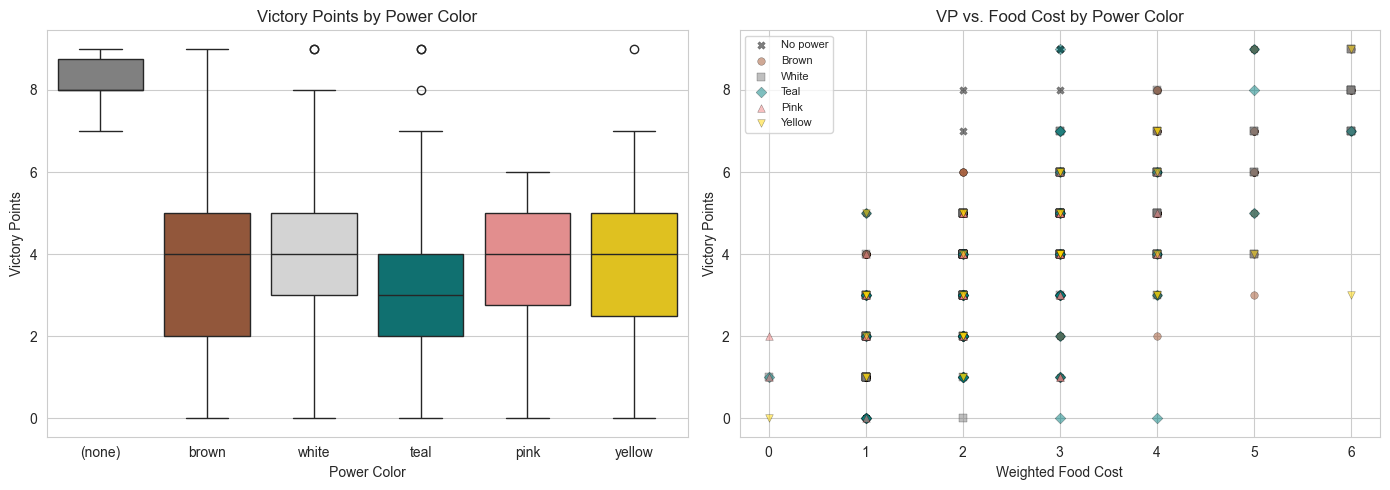

In [34]:
# VP distribution by power color
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: VP by color
color_order = ["(none)", "brown", "white", "teal", "pink", "yellow"]

plot_color = feat["color"].fillna("(none)")

sns.boxplot(
    x=plot_color,
    y=feat["victory_points"],
    order=color_order,
    ax=axes[0],
    hue=plot_color,
    palette={
        "(none)": "grey",
        "brown": "sienna",
        "white": "lightgrey",
        "teal": "teal",
        "pink": "lightcoral",
        "yellow": "gold"
    },
    legend=False,
)

axes[0].set_xlabel("Power Color")
axes[0].set_ylabel("Victory Points")
axes[0].set_title("Victory Points by Power Color")

# VP vs weighted food cost, colored by power
for color_val, marker, c in [
    (np.nan, "X", "black"),
    ("brown", "o", "sienna"),
    ("white", "s", "grey"),
    ("teal", "D", "teal"),
    ("pink", "^", "lightcoral"),
    ("yellow", "v", "gold")
]:  
    if pd.isna(color_val):
        mask = feat["color"].isna()
        label = "No power"
    else:
        mask = feat["color"] == color_val
        label = color_val.capitalize()
    axes[1].scatter(
        feat.loc[mask, "weighted_food_cost"],
        feat.loc[mask, "victory_points"],
        marker=marker,
        c=c,
        alpha=0.5,
        s=30,
        label=label,
        edgecolors="k",
        linewidths=0.3
    )

axes[1].set_xlabel("Weighted Food Cost")
axes[1].set_ylabel("Victory Points")
axes[1].set_title("VP vs. Food Cost by Power Color")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../output/vp_by_color_exploration.png", dpi=150, bbox_inches="tight")
plt.show();

In [35]:
# Summary statistics by power color
summary_cols = [
    "victory_points",
    "weighted_food_cost",
    "total_food_cost",
    "egg_limit",
    "bonus_count",
    "habitat_count"
]
color_summary = feat.groupby(feat["color"].fillna("(none)"))[summary_cols].agg(["mean", "median", "count"])
color_summary.columns = [f"{col}_{stat}" for col, stat in color_summary.columns]
color_summary = color_summary.reindex(["(none)", "brown", "white", "teal", "pink", "yellow"])

print(color_summary.round(2).to_string())

        victory_points_mean  victory_points_median  victory_points_count  weighted_food_cost_mean  weighted_food_cost_median  weighted_food_cost_count  total_food_cost_mean  total_food_cost_median  total_food_cost_count  egg_limit_mean  egg_limit_median  egg_limit_count  bonus_count_mean  bonus_count_median  bonus_count_count  habitat_count_mean  habitat_count_median  habitat_count_count
color                                                                                                                                                                                                                                                                                                                                                                                                 
(none)                 8.17                    8.0                     6                     2.83                        3.0                         6                  2.67                     3.0                      

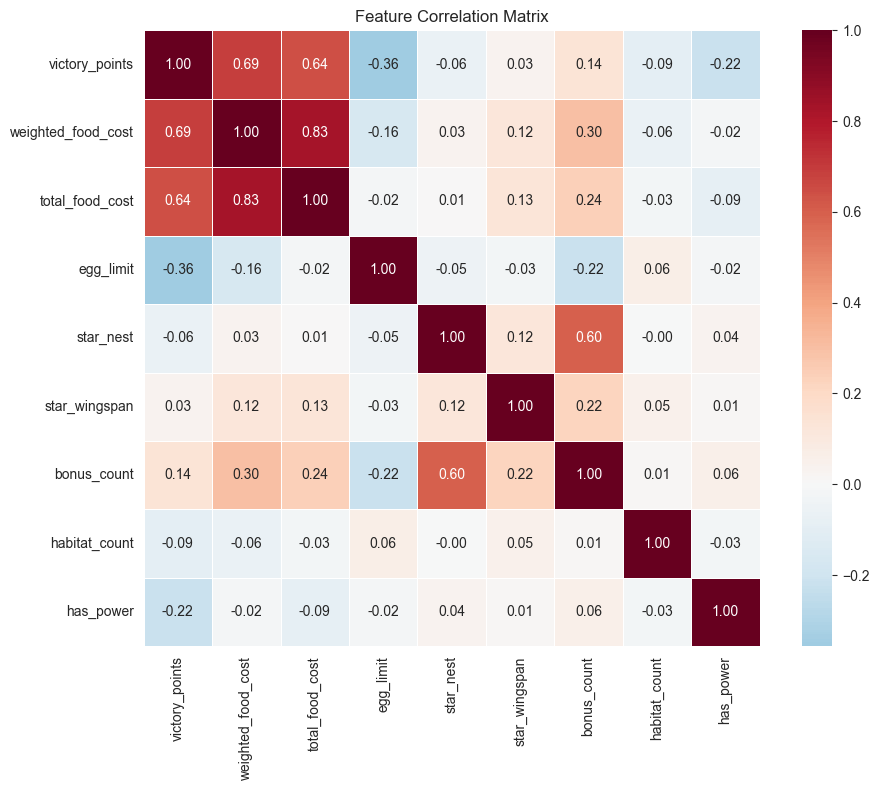

In [36]:
# Correlation matrix of key numeric features
corr_cols = [
    "victory_points",
    "weighted_food_cost",
    "total_food_cost",
    "egg_limit",
    "star_nest",
    "star_wingspan",
    "bonus_count",
    "habitat_count",
    "has_power"
]

corr = feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5
)

ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../output/feature_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show();

---
## Stage 1: Baseline Model (Non-Power Attributes)

Regress Victory Points on attributes that are **independent of the bird's power**:
- Weighted food cost (rarity-adjusted)
- Egg limit
- Nest type dummies (reference: ground)
- Star nest and star wingspan indicators
- Bonus card eligibility count
- Habitat count (flexibility of placement)
- Predator cost indicator (the `*` mechanic is part of the power, flagged here)

**Hypothesis:** Higher food cost → higher VP (you pay more, you get more points).
Powerless birds should be well-explained by this model since their VP is their
entire value proposition.

In [37]:
# Stage 1 feature set
stage1_features = [
    "weighted_food_cost",
    "egg_limit",
    "star_nest",
    "nest_none",
    "nest_bowl",
    "nest_cavity",
    "nest_platform",
    "star_wingspan",
    "bonus_count",
    "habitat_count",
    "has_predator_cost",
]

X1 = sm.add_constant(feat[stage1_features])
y = feat["victory_points"]

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:         victory_points   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     69.35
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           2.06e-98
Time:                        13:15:34   Log-Likelihood:                -1006.9
No. Observations:                 596   AIC:                             2038.
Df Residuals:                     584   BIC:                             2090.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.7521      0

In [38]:
# How well does Stage 1 explain powerless birds?
powerless_idx = feat[feat["has_power"] == 0].index
powerless_pred = model1.predict(X1.loc[powerless_idx])
powerless_actual = y.loc[powerless_idx]
powerless_resid = powerless_actual - powerless_pred

print("Stage 1 — Powerless bird fit:")
print("="*60)
for idx in powerless_idx:
    name = feat.loc[idx, "common_name"]
    actual = y.loc[idx]
    pred = model1.predict(X1.loc[[idx]]).iloc[0]
    print(f"  {name:<25} Actual: {actual:.0f}  Predicted: {pred:.1f}  Residual: {actual - pred:+.1f}")

print(f"\n  MAE (powerless):  {powerless_resid.abs().mean():.2f}")
print(f"  RMSE (powerless): {np.sqrt((powerless_resid**2).mean()):.2f}")
print(f"\n  MAE (all birds):  {model1.resid.abs().mean():.2f}")
print(f"  RMSE (all birds): {np.sqrt((model1.resid**2).mean()):.2f}")

Stage 1 — Powerless bird fit:
  American Woodcock         Actual: 9  Predicted: 5.1  Residual: +3.9
  Blue-Winged Warbler       Actual: 8  Predicted: 3.5  Residual: +4.5
  Hooded Warbler            Actual: 7  Predicted: 3.5  Residual: +3.5
  Prothonotary Warbler      Actual: 8  Predicted: 3.8  Residual: +4.2
  Trumpeter Swan            Actual: 9  Predicted: 5.0  Residual: +4.0
  Wild Turkey               Actual: 8  Predicted: 4.7  Residual: +3.3

  MAE (powerless):  3.89
  RMSE (powerless): 3.91

  MAE (all birds):  1.02
  RMSE (all birds): 1.31


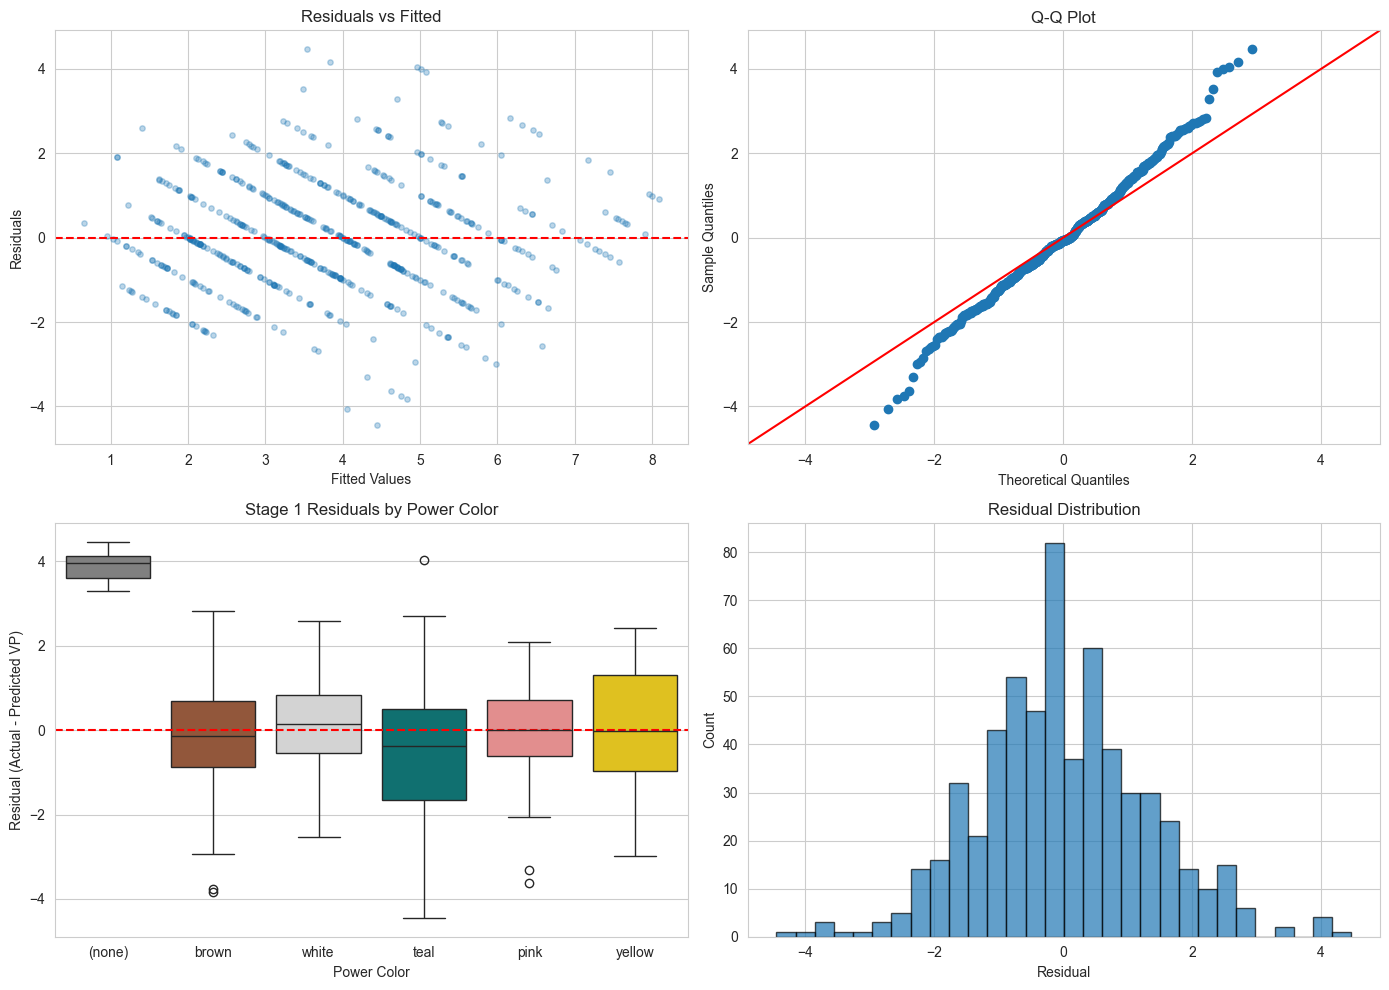


Mean residual by power color (Stage 1):
        mean   std  count
color                    
(none)  3.89  0.43      6
brown  -0.06  1.20    342
white   0.17  1.05    122
teal   -0.45  1.71     51
pink   -0.02  1.25     40
yellow  0.02  1.57     35


In [39]:
# Stage 1 residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs fitted
axes[0, 0].scatter(model1.fittedvalues, model1.resid, alpha=0.3, s=15)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# QQ plot
sm.qqplot(model1.resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot")

# Residuals by power color
resid_df = pd.DataFrame({"residual": model1.resid, "color": feat["color"].fillna("(none)")})
color_order = ["(none)", "brown", "white", "teal", "pink", "yellow"]
sns.boxplot(
    data=resid_df,
    x="color",
    y="residual",
    hue="color",
    order=color_order,
    ax=axes[1, 0],
    palette={
        "(none)": "grey",
        "brown": "sienna",
        "white": "lightgrey",
        "teal": "teal",
        "pink": "lightcoral",
        "yellow": "gold"
    },
    legend=False,
)

axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("Power Color")
axes[1, 0].set_ylabel("Residual (Actual - Predicted VP)")
axes[1, 0].set_title("Stage 1 Residuals by Power Color")

# Histogram of residuals
axes[1, 1].hist(model1.resid, bins=30, edgecolor="black", alpha=0.7)
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("../output/stage1_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# Mean residual by color (should reveal systematic patterns)
print("\nMean residual by power color (Stage 1):")
print(
    resid_df
    .groupby("color")["residual"]
    .agg(["mean", "std", "count"])
    .reindex(color_order)
    .round(2)
)

---
## Stage 2: Adding Power Color

Now add power color dummies. The reference group is **non-powered birds** ("Color" = null).

Each color coefficient represents the average VP adjustment the game designers made for birds of that power color, *controlling for food cost, nest, and other attributes*.

Here we expect to see *negative coefficients* for powers - birds with powers have lower VP, which compensates for the power's value. The magnitude tells us the implicit VP value of each
power-color category. More valuable power colors should have more negative coefficients.

In [40]:
# Stage 2 feature set
stage2_features = stage1_features + [
    "color_brown",
    "color_white",
    "color_teal",
    "color_pink",
    "color_yellow",
]

X2 = sm.add_constant(feat[stage2_features])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         victory_points   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     57.11
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          1.02e-107
Time:                        13:15:34   Log-Likelihood:                -973.69
No. Observations:                 596   AIC:                             1981.
Df Residuals:                     579   BIC:                             2056.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  7.5405      0

In [41]:
# Extract and visualize power color coefficients
color_coefs = pd.DataFrame(
    {
        "color": ["brown", "white", "teal", "pink", "yellow"],
        "coefficient": [model2.params[f"color_{c}"] for c in ["brown", "white", "teal", "pink", "yellow"]],
        "std_err": [model2.bse[f"color_{c}"] for c in ["brown", "white", "teal", "pink", "yellow"]],
        "pvalue": [model2.pvalues[f"color_{c}"] for c in ["brown", "white", "teal", "pink", "yellow"]],
    }
)

color_coefs["ci_lower"] = color_coefs["coefficient"] - 1.96 * color_coefs["std_err"]
color_coefs["ci_upper"] = color_coefs["coefficient"] + 1.96 * color_coefs["std_err"]
color_coefs["significant"] = color_coefs["pvalue"] < 0.05

print("Power Color Coefficients (relative to powerless birds):")
print("="*75)
print(color_coefs.to_string(index=False, float_format="{:.3f}".format))
print("\nInterpretation: A negative coefficient means birds with that power color")
print("have LOWER VP than expected, implying the power's value 'costs' that many VP.")

Power Color Coefficients (relative to powerless birds):
 color  coefficient  std_err  pvalue  ci_lower  ci_upper  significant
 brown       -4.002    0.521   0.000    -5.023    -2.981         True
 white       -3.750    0.530   0.000    -4.790    -2.710         True
  teal       -4.403    0.546   0.000    -5.474    -3.332         True
  pink       -3.964    0.561   0.000    -5.064    -2.864         True
yellow       -3.939    0.562   0.000    -5.040    -2.838         True

Interpretation: A negative coefficient means birds with that power color
have LOWER VP than expected, implying the power's value 'costs' that many VP.


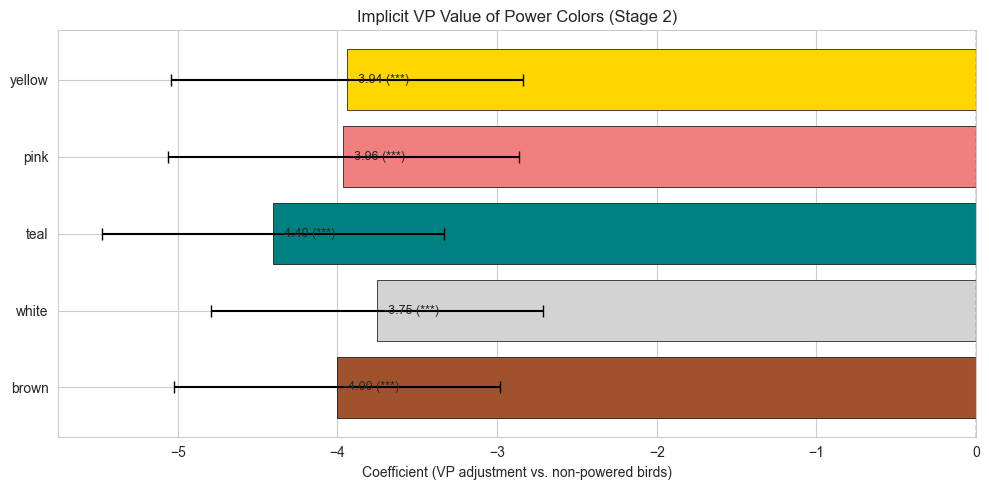

In [ ]:
# Visualize power color coefficients with confidence intervals
fig, ax = plt.subplots(figsize=(10, 5))

colors_palette = {
    "brown": "sienna",
    "white": "lightgrey",
    "teal": "teal",
    "pink": "lightcoral",
    "yellow": "gold"
}
bar_colors = [colors_palette[c] for c in color_coefs["color"]]

bars = ax.barh(
    y=color_coefs["color"],
    width=color_coefs["coefficient"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

ax.errorbar(
    x=color_coefs["coefficient"],
    y=color_coefs["color"],
    xerr=(1.96 * color_coefs["std_err"]),
    fmt="none",
    ecolor="black",
    capsize=4,
)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Coefficient (VP adjustment vs. non-powered birds)")
ax.set_title("Implicit VP Value of Power Colors (Stage 2)")

# Add p-value annotations
for i, row in color_coefs.iterrows():
    sig = "***" if row["pvalue"] < 0.001 else "**" if row["pvalue"] < 0.01 else "*" if row["pvalue"] < 0.05 else "ns"
    ax.annotate(
        f"  {row['coefficient']:.2f} ({sig})",
        xy=(row["coefficient"], row["color"]),
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("../output/power_color_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
# Model comparison: Stage 1 vs Stage 2
print("Model Comparison")
print("="*60)
print(f"{'Metric':<30} {'Stage 1':>12} {'Stage 2':>12}")
print("-"*60)
print(f"{'R-squared':<30} {model1.rsquared:>12.4f} {model2.rsquared:>12.4f}")
print(f"{'Adj. R-squared':<30} {model1.rsquared_adj:>12.4f} {model2.rsquared_adj:>12.4f}")
print(f"{'AIC':<30} {model1.aic:>12.1f} {model2.aic:>12.1f}")
print(f"{'BIC':<30} {model1.bic:>12.1f} {model2.bic:>12.1f}")
print(f"{'RMSE':<30} {np.sqrt(model1.mse_resid):>12.3f} {np.sqrt(model2.mse_resid):>12.3f}")
print(f"{'MAE':<30} {model1.resid.abs().mean():>12.3f} {model2.resid.abs().mean():>12.3f}")
print(f"{'F-statistic':<30} {model1.fvalue:>12.1f} {model2.fvalue:>12.1f}")
print(f"{'Num features':<30} {model1.df_model:>12.0f} {model2.df_model:>12.0f}")

# F-test for the incremental value of power color dummies
f_test = model2.compare_f_test(model1)
print(f"\nF-test (Stage 2 vs Stage 1): F={f_test[0]:.3f}, p={f_test[1]:.4f}")
print(f"Adding power colors {'significantly' if f_test[1] < 0.05 else 'does not significantly'} improve the model.")

Model Comparison
Metric                              Stage 1      Stage 2
------------------------------------------------------------
R-squared                            0.5664       0.6121
Adj. R-squared                       0.5582       0.6014
AIC                                  2037.8       1981.4
BIC                                  2090.5       2056.0
RMSE                                  1.324        1.258
MAE                                   1.016        0.972
F-statistic                            69.4         57.1
Num features                             11           16

F-test (Stage 2 vs Stage 1): F=13.651, p=0.0000
Adding power colors significantly improve the model.


C:\Users\User\AppData\Local\Temp\ipykernel_23800\4070225550.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="color", y="residual", data=resid2_df, order=color_order, ax=axes[1],


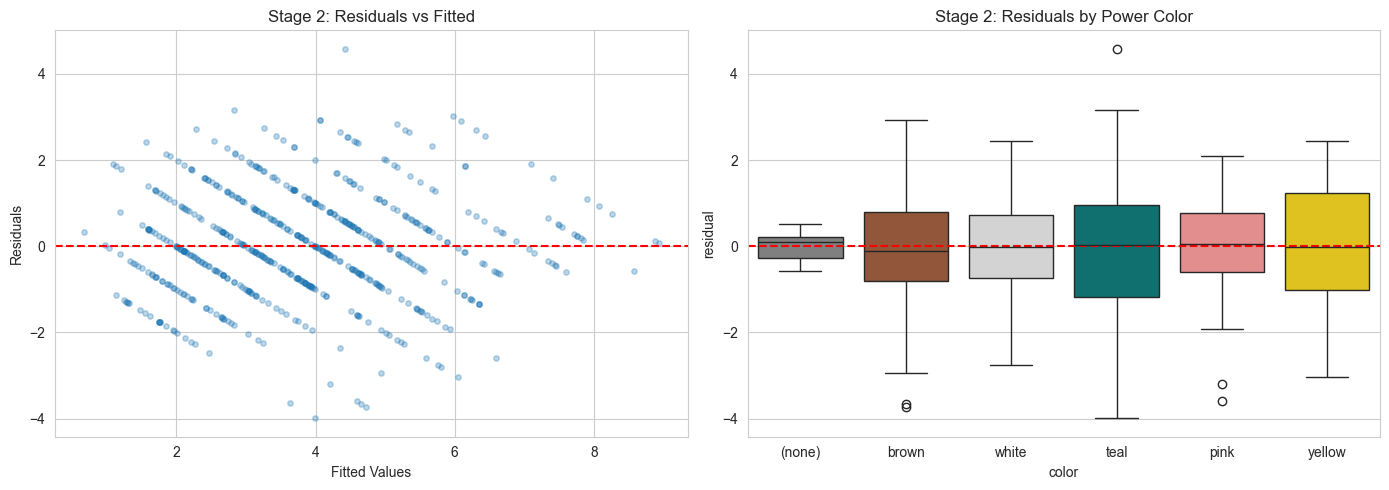


Mean residual by power color (Stage 2):
        mean   std  count
color                    
(none)  -0.0  0.41      6
brown   -0.0  1.20    342
white   -0.0  1.06    122
teal    -0.0  1.72     51
pink    -0.0  1.24     40
yellow  -0.0  1.57     35


In [ ]:
# Stage 2 residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs fitted
axes[0].scatter(model2.fittedvalues, model2.resid, alpha=0.3, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Stage 2: Residuals vs Fitted")

# Residuals by color
resid2_df = pd.DataFrame({"residual": model2.resid, "color": feat["color"].fillna("(none)")})
sns.boxplot(
    data=resid2_df,
    x="color",
    y="residual",
    hue="color",
    order=color_order,
    ax=axes[1],
    palette={
        "(none)": "grey",
        "brown": "sienna",
        "white": "lightgrey",
                     "teal": "teal", "pink": "lightcoral", "yellow": "gold"}
)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Stage 2: Residuals by Power Color")

plt.tight_layout()
plt.savefig("../output/stage2_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMean residual by power color (Stage 2):")
print(resid2_df.groupby("color")["residual"].agg(["mean", "std", "count"]).reindex(color_order).round(2))

In [45]:
# All Stage 2 coefficients in one clean table
coef_table = pd.DataFrame({
    "coefficient": model2.params,
    "std_err": model2.bse,
    "t_stat": model2.tvalues,
    "p_value": model2.pvalues,
    "ci_lower": model2.conf_int()[0],
    "ci_upper": model2.conf_int()[1],
})
coef_table["significant"] = coef_table["p_value"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
)
print("\nFull Stage 2 Coefficient Table:")
print(coef_table.round(4).to_string())


Full Stage 2 Coefficient Table:
                    coefficient  std_err   t_stat  p_value  ci_lower  ci_upper significant
const                    7.5405   0.6196  12.1701   0.0000    6.3236    8.7575         ***
weighted_food_cost       1.0189   0.0430  23.7125   0.0000    0.9345    1.1032         ***
egg_limit               -0.4598   0.0466  -9.8707   0.0000   -0.5513   -0.3683         ***
star_nest               -0.4999   0.2236  -2.2354   0.0258   -0.9392   -0.0607           *
nest_none               -1.1460   0.5561  -2.0607   0.0398   -2.2382   -0.0538           *
nest_bowl               -0.3194   0.1531  -2.0863   0.0374   -0.6200   -0.0187           *
nest_cavity             -0.3667   0.1537  -2.3862   0.0173   -0.6684   -0.0649           *
nest_platform           -0.3827   0.1673  -2.2881   0.0225   -0.7112   -0.0542           *
star_wingspan           -0.6959   0.4413  -1.5769   0.1154   -1.5626    0.1708            
bonus_count             -0.1076   0.0459  -2.3432   0.019

---
## Summary & Next Steps

**What we've established so far:**
- Stage 1 baseline captures the VP-cost tradeoff across all birds
- Stage 2 quantifies the average VP "cost" of having each power color
- Residual patterns by color reveal how much variance remains within each color

**Stage 3 (next notebook):**
- Parse power text to extract specific mechanics (gain food, draw cards, lay eggs, etc.)
- Model within-color variation based on power mechanics
- Account for activation counts by power color
  - Brown: scales with number of actions in the row
  - Pink: scales with other players' actions
  - Teal: exactly 4 activations (end of each round)
  - White: exactly 1 activation (when played)
  - Yellow: exactly 1 activation (end of game)